In [1]:
!piip install yfinance

/bin/bash: line 1: piip: command not found


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
df = yf.download("BTC-USD", start="2020-01-01", end="2025-01-01")
df.reset_index(inplace=True)

/tmp/ipykernel_503/1641731251.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

prices = df['Close'].values.flatten()

Sliding Window Feature Engineering

In [5]:
WINDOW = 5

X = []
Y = []

for i in range(len(prices) - WINDOW):
  window = prices[i:i+WINDOW]

  returns = np.diff(window) / window[:-1]
  mean_return = returns.mean()
  volatility = returns.std()

  X.append([mean_return, volatility])

  #Bullish = price goes up next day
  Y.append(1 if prices[i+WINDOW] > window[-1] else 0)

X = np.array(X)
Y = np.array(Y)

Prefix Sum Optimization

In [6]:
prefix_sum = np.cumsum(prices)

def window_mean(l, r):
  return (prefix_sum[r] - prefix_sum[l]) / (r - l)

Training Random Forest Model

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    random_state=42
    )

model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=6, n_estimators=150, random_state=42)

In [8]:
preds = model.predict(X_test)

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
successful_patterns = (preds == Y_test).sum()
total_patterns = len(Y_test)

Visualization

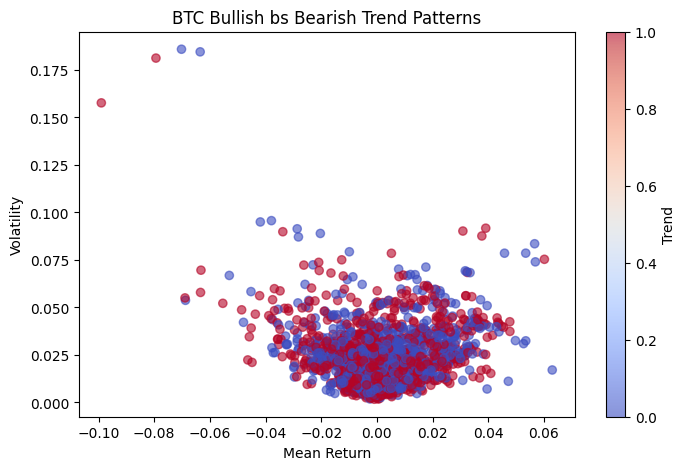

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X[:,0], X[:,1],
    c=Y,
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Mean Return")
plt.ylabel("Volatility")
plt.title("BTC Bullish bs Bearish Trend Patterns")
plt.colorbar(label="Trend")
plt.show()

In [12]:
latest_window = prices[-WINDOW:]
returns = np.diff(latest_window) / latest_window[:-1]

feature = [[returns.mean(), returns.std()]]
prediction = model.predict(feature)

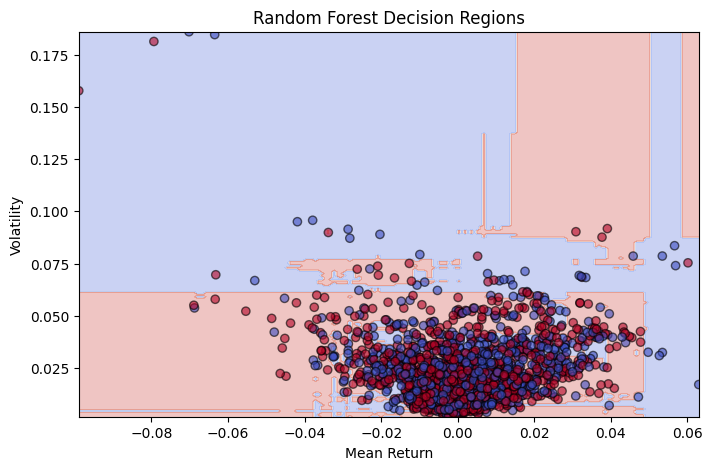

In [13]:
import numpy as np

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 200),
    np.linspace(X[:,1].min(), X[:,1].max(), 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', edgecolor='k', alpha=0.6)
plt.xlabel("Mean Return")
plt.ylabel("Volatility")
plt.title("Random Forest Decision Regions")
plt.show()


Backtesting

In [14]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

model.fit(X_train, Y_train)

predictions = model.predict(X_test)


In [15]:
test_prices = prices[split + WINDOW:]

In [16]:
initial_capital = 10000
capital = initial_capital
position = 0

portfolio_values = []

for i in range(len(predictions)):
    price = test_prices[i]

    # Safety check
    if np.isnan(price) or price <= 0:
        portfolio_values.append(capital)
        continue

    if predictions[i] == 1 and position == 0:
        position = capital / price
        capital = 0

    elif predictions[i] == 0 and position > 0:
        capital = position * price
        position = 0

    portfolio_values.append(capital + position * price)

# Final liquidation
if position > 0:
    capital = position * test_prices[-1]
    position = 0
    portfolio_values[-1] = capital


In [17]:
buy_hold = initial_capital*(test_prices / test_prices[0])

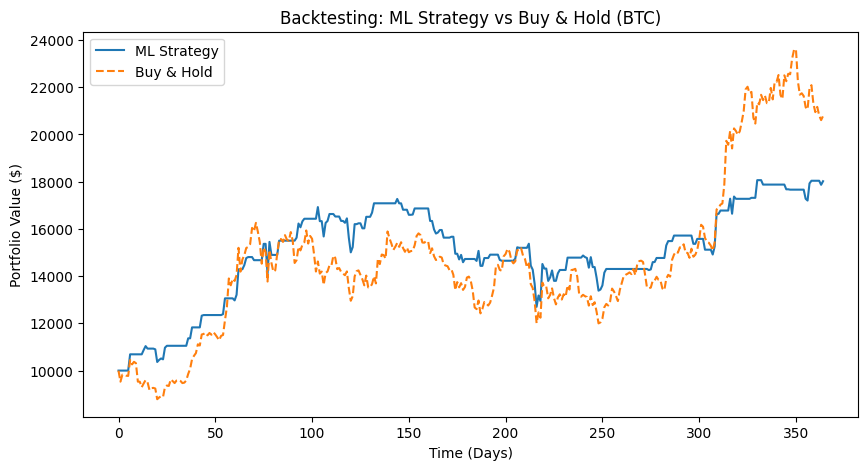

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(portfolio_values, label="ML Strategy")
plt.plot(buy_hold, label="Buy & Hold", linestyle="--")

plt.xlabel("Time (Days)")
plt.ylabel("Portfolio Value ($)")
plt.title("Backtesting: ML Strategy vs Buy & Hold (BTC)")
plt.legend()
plt.show()


In [19]:
final_ml = portfolio_values[-1]
final_bh = buy_hold[-1]

ml_return = (final_ml - initial_capital) / initial_capital * 100
bh_return = (final_bh - initial_capital) / initial_capital * 100